#PROJECT-TITLE:
Exploratory Data Analysis on Suicide Trends and Causes in India



In [ ]:
#importing Required libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/updated_suicide_dataset (6).csv")

#PROBLEM-STATEMENET
India records a significant number of suicides every year due to various social, financial, psychological, and personal causes. Understanding the trends and identifying high-risk groups can help policymakers and researchers create better awareness and prevention strategies.


This project aims to analyze suicide data across different states, genders, years, and causes to uncover patterns, trends, and major contributing factors behind suicides in India.


In [ ]:
#checking data information:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16020 entries, 0 to 16019
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                16020 non-null  int64  
 1   year              16020 non-null  int64  
 2   state_name        16020 non-null  object 
 3   state_code        16020 non-null  int64  
 4   cause             16020 non-null  object 
 5   gender            16020 non-null  object 
 6   number_of_deaths  16020 non-null  float64
 7   severity_level    16020 non-null  object 
 8   risk_category     16020 non-null  object 
 9   decade            16020 non-null  object 
 10  age_group         16020 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 1.3+ MB


#basic information about data
1.Catagorical-columns:(age_group,decade,state_name,cause,gender,severity level,risk_category)

2.Numerical-Columns:(id,year,state_code,number_of_deaths)


#checking null values:

In [ ]:
data.isnull().sum()/len(data)

,0
id,0.0
year,0.0
state_name,0.0
state_code,0.0
cause,0.0
gender,0.0
number_of_deaths,0.0
severity_level,0.0
risk_category,0.0
decade,0.0


No null values presnt in this  data set

In [ ]:
#checking duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
#UNDERSTANDING DATA SET
data.shape

(16020, 11)

In [ ]:
data.describe()

,id,year,state_code,number_of_deaths
count,16020.000000,16020.000000,16020.000000,16020.000000
mean,8009.500000,2020.016854,18.966292,58.575343
std,4624.719992,1.412169,11.072580,263.247125
min,0.000000,2018.000000,1.000000,0.000000
25%,4004.750000,2019.000000,9.000000,0.000000
50%,8009.500000,2020.000000,18.000000,0.000000
75%,12014.250000,2021.000000,29.000000,11.000000
max,16019.000000,2022.000000,38.000000,5481.000000


YEAR-WISE ANALYSIS:

In [ ]:
data.head()

,id,year,state_name,state_code,cause,gender,number_of_deaths,severity_level,risk_category,decade,age_group
0,0,2018,Andaman And Nicobar Islands,35,Bankruptcy Or Indebtedness,Female,1.0,Low,Financial,2010s,45-59
1,1,2018,Andaman And Nicobar Islands,35,Bankruptcy Or Indebtedness,Male,4.0,Low,Financial,2010s,45-59
2,2,2018,Andaman And Nicobar Islands,35,Bankruptcy Or Indebtedness,Transgender,0.0,Low,Financial,2010s,45-59
3,3,2018,Andaman And Nicobar Islands,35,Causes Not Known,Female,7.0,Low,Psychological,2010s,25-44
4,4,2018,Andaman And Nicobar Islands,35,Causes Not Known,Male,7.0,Low,Psychological,2010s,25-44


In [ ]:
#How have suicide deaths changed over the years?
yearly = data.groupby('year')['number_of_deaths'].sum()

yearly

,number_of_deaths
year,
2018,166564.0
2019,170548.0
2020,188311.0
2021,202382.0
2022,210572.0


#OBSERVATION:
yearly-from 2018 no.of deaths were increaing rapidly,and in (2020-2021) deaths percentage were increased more campared to previous years.

In [ ]:
#Which year recorded the highest number of suicides?
yearly.sort_values(ascending=False).head()

,number_of_deaths
year,
2022,210572.0
2021,202382.0
2020,188311.0
2019,170548.0
2018,166564.0


#OBSERVATION:
In (2022) deaths percantage is high as campared to previous years-210572.0 deaths were noted.

In [ ]:
#Is there an increasing or decreasing trend over time?
yearly.iloc[0]

np.float64(166564.0)

In [ ]:
yearly.iloc[-1]

np.float64(210572.0)

#observation:
deaths were increasing year-by-year.
overall trends were raising rapidly.

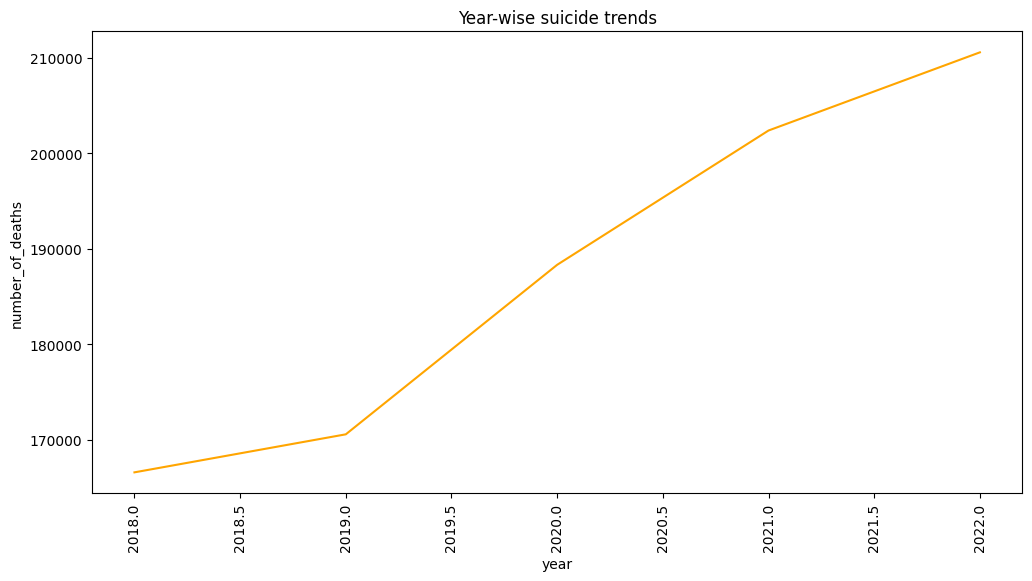

In [ ]:
#visual-analysis:
yearly.sort_values(ascending=False).head(10).plot(kind="line",
                        color="orange",figsize=(12,6))
plt.title("Year-wise suicide trends")
plt.xlabel("year")
plt.ylabel('number_of_deaths')
plt.xticks(rotation=90)
plt.show()

In [ ]:
data["top"]=data["cause"].head(5).sort_values(ascending=False)

#STATE-WISE-ANALYSIS

In [ ]:
data.head()

,id,year,state_name,state_code,cause,gender,number_of_deaths,severity_level,risk_category,decade,age_group,top
0,0,2018,Andaman And Nicobar Islands,35,Bankruptcy Or Indebtedness,Female,1.0,Low,Financial,2010s,45-59,Bankruptcy Or Indebtedness
1,1,2018,Andaman And Nicobar Islands,35,Bankruptcy Or Indebtedness,Male,4.0,Low,Financial,2010s,45-59,Bankruptcy Or Indebtedness
2,2,2018,Andaman And Nicobar Islands,35,Bankruptcy Or Indebtedness,Transgender,0.0,Low,Financial,2010s,45-59,Bankruptcy Or Indebtedness
3,3,2018,Andaman And Nicobar Islands,35,Causes Not Known,Female,7.0,Low,Psychological,2010s,25-44,Causes Not Known
4,4,2018,Andaman And Nicobar Islands,35,Causes Not Known,Male,7.0,Low,Psychological,2010s,25-44,Causes Not Known


In [ ]:
#Which states recorded the highest suicide deaths?
state_wise=data.groupby("state_name")["number_of_deaths"].sum().sort_values(ascending=False)
state_wise

,number_of_deaths
state_name,
Maharashtra,124697.0
Tamil Nadu,107326.0
Madhya Pradesh,88661.0
Karnataka,79771.0
West Bengal,75279.0
Kerala,55818.0
Gujarat,51644.0
Telangana,49999.0
Andhra Pradesh,46946.0


OBSERVATION:

(Maharashtra	124697.0
Tamil Nadu	107326.0)
Maharasthra and Tamil-Nadu states records highest no.of suicide deaths.



In [ ]:
#Which states recorded the lowest suicide deaths?
state_wise=data.groupby("state_name")["number_of_deaths"].sum().sort_values(ascending=True)
state_wise

,number_of_deaths
state_name,
Lakshadweep,12.0
Ladakh,43.0
Nagaland,240.0
Manipur,246.0
Mizoram,603.0
Arunachal Pradesh,741.0
Chandigarh,747.0
The Dadra And Nagar Haveli And Daman And Diu,974.0
Andaman And Nicobar Islands,1163.0


OBSERVATION:

(Lakshadweep	12.0
Ladakh	43.0)
lakshadweep state and ladakh recorded the lowest suicide deaths.


In [ ]:
trend = data.groupby(['year', 'state_name'])['number_of_deaths'].sum().reset_index()

In [ ]:
pivot = trend.pivot(index='year', columns='state_name', values='number_of_deaths')

In [ ]:
increase = pivot.iloc[-1] - pivot.iloc[0]

increase.sort_values(ascending=False).head(10)

,0
state_name,
Tamil Nadu,9457.0
Maharashtra,5262.0
Madhya Pradesh,4683.0
Andhra Pradesh,4217.0
Uttar Pradesh,3809.0
Telangana,3251.0
Kerala,1899.0
Karnataka,1876.0
Chhattisgarh,1575.0


OBSERVATION:
Tamil-nadu state shows fastest increase in suicides over time.

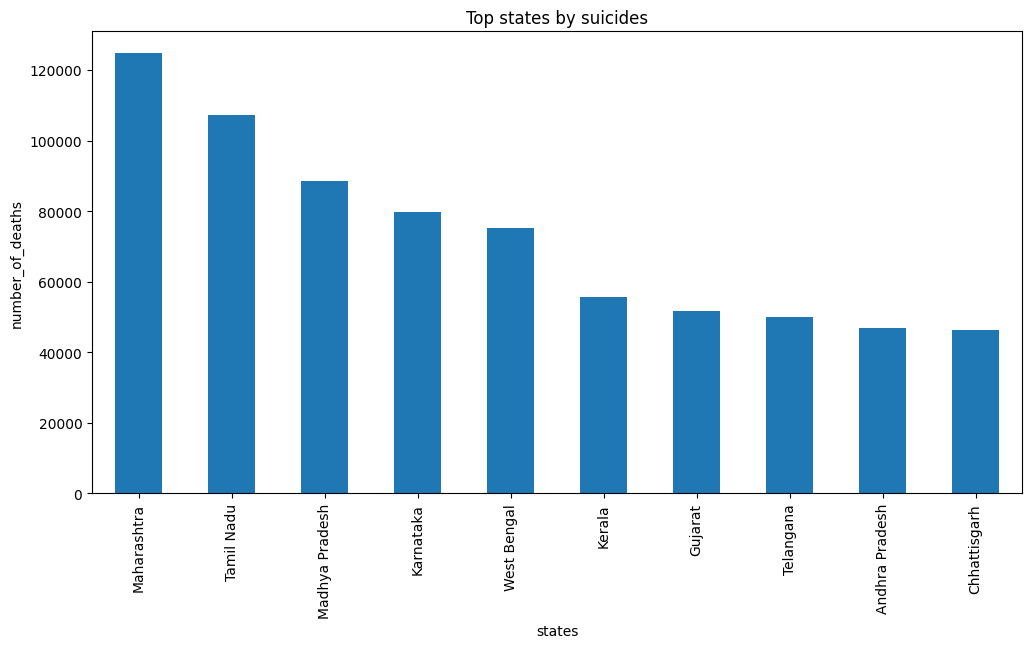

In [ ]:
state_wise.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(12,6))
plt.title("Top states by suicides")
plt.xlabel("states")
plt.ylabel("number_of_deaths")
plt.xticks(rotation=90)
plt.show()

CAUSE-WISE-ANALYSIS

In [ ]:
causewise = data.groupby('cause')['number_of_deaths'].sum().sort_values(ascending=False)

causewise.sort_values(ascending=False).head(10)

,number_of_deaths
cause,
Family Problems,246089.0
Illness (Total),137147.0
Other Causes,80231.0
Causes Not Known,78750.0
Illness (Insanity/Mental Illness),63331.0
Illness (Other Prolonged Illness),61581.0
Drug Abuse/Alcoholic Addiction,46416.0
Marriage Related Issues (Total),39582.0
Love Affairs,33602.0


OBSERVATION:
many people commiting suicides beacause of family problems as campared to other.

In [ ]:
#Which causes contribute the least?
causewise = data.groupby('cause')['number_of_deaths'].sum().sort_values(ascending=True)
causewise.head()

,number_of_deaths
cause,
Illegitimate Pregnancy (Other Than Extra Marital Affairs),179.0
"Physical Abuse (Rape, Etc.)",524.0
Ideological Causes/Hero Worshipping,723.0
Illness (Aids/Std),862.0
Impotency/Infertility,1796.0


OBSERVATION:
Illegitimate Pregnancy (Other Than Extra Marital Affairs)	cause contributed the least deaths.

In [ ]:
#Which causes are most common among males and females
gender_cause = pd.crosstab(data['cause'], data['gender'],
                           values=data['number_of_deaths'],
                           aggfunc='sum')
gender_cause.head()

gender,Female,Male,Transgender
cause,,,
Bankruptcy Or Indebtedness,2556.0,26929.0,1.0
Causes Not Known,23493.0,55250.0,7.0
Death Of Dear Person,2598.0,5111.0,2.0
Drug Abuse/Alcoholic Addiction,1000.0,45410.0,6.0
Failure In Examination,4911.0,6306.0,0.0


In [ ]:
gender_cause['Male'].sort_values(ascending=False).head(10)

,Male
cause,
Family Problems,168639.0
Illness (Total),94910.0
Other Causes,56521.0
Causes Not Known,55250.0
Drug Abuse/Alcoholic Addiction,45410.0
Illness (Insanity/Mental Illness),44545.0
Illness (Other Prolonged Illness),41206.0
Bankruptcy Or Indebtedness,26929.0
Love Affairs,20249.0


OBSERVATION:
family-problems are the most common cause for male deaths.

In [ ]:
gender_cause['Female'].sort_values(ascending=False).head(10)

,Female
cause,
Family Problems,77423.0
Illness (Total),42206.0
Other Causes,23696.0
Causes Not Known,23493.0
Marriage Related Issues (Total),20954.0
Illness (Other Prolonged Illness),20358.0
Illness (Insanity/Mental Illness),18775.0
Love Affairs,13348.0
Marriage Related Issues (Dowry Related Issues),8480.0


OBSERVATION:
for females also family problems are the main cause for suicidal deaths.

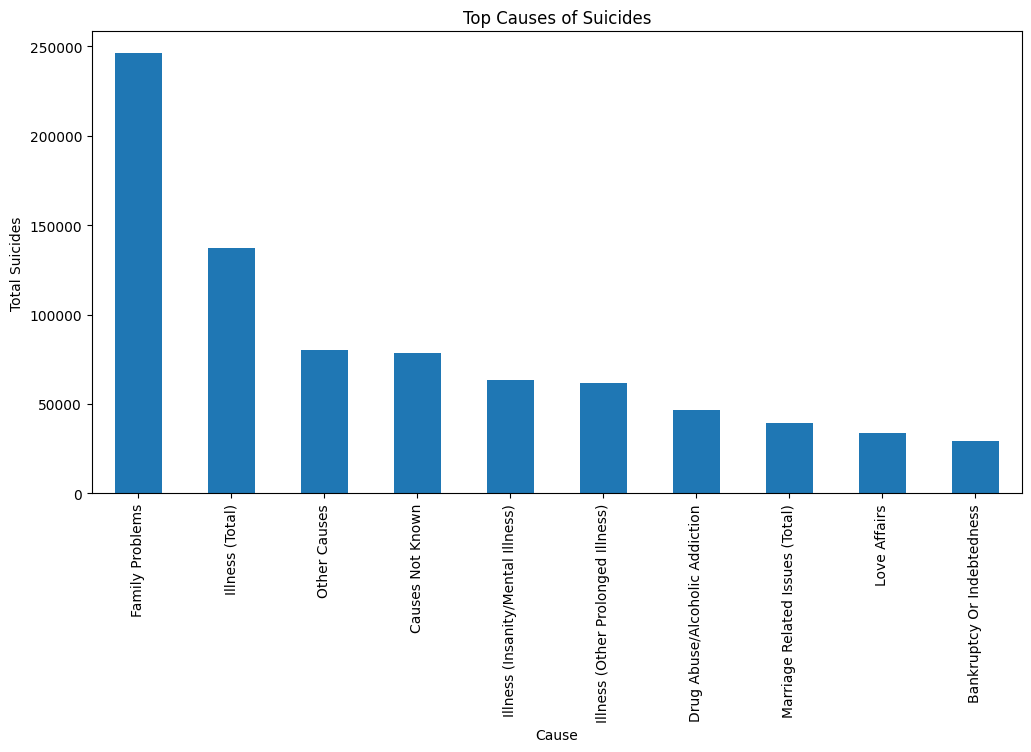

In [ ]:
causewise.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(12,6)
)
plt.title('Top Causes of Suicides')
plt.xlabel('Cause')
plt.ylabel('Total Suicides')
plt.xticks(rotation=90)
plt.show()


GENDER-WISE-ANALYSIS

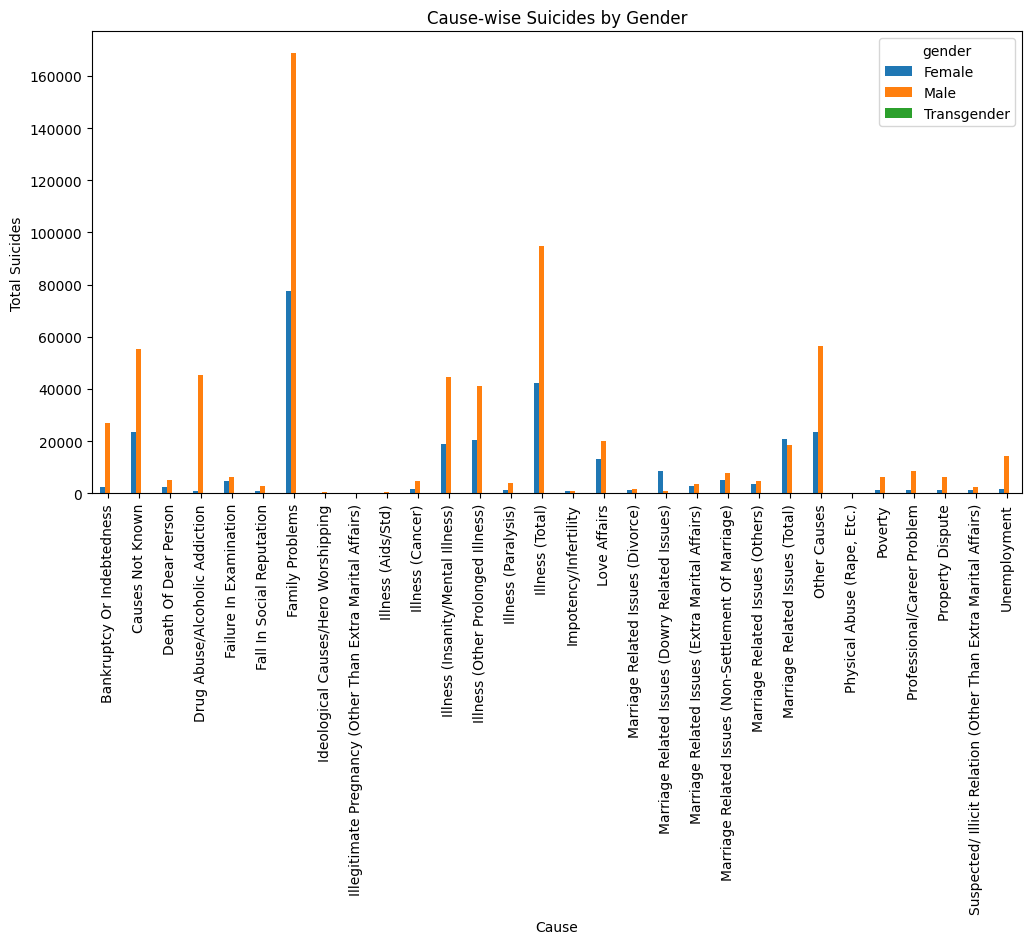

In [ ]:
gender_cause.plot(kind='bar', figsize=(12,6))
plt.title('Cause-wise Suicides by Gender')
plt.xlabel('Cause')
plt.ylabel('Total Suicides')
plt.xticks(rotation=90)
plt.show()

In [ ]:
gender_wise=data.groupby("gender")["number_of_deaths"].sum()
gender_wise.head()

,number_of_deaths
gender,
Female,284740.0
Male,653498.0
Transgender,139.0


OBSERVATION:

male gender contributed more deaths campared to female

In [ ]:
state_cause = data.pivot_table(values='number_of_deaths',
                             index='state_name',
                             columns='cause',
                             aggfunc='sum')

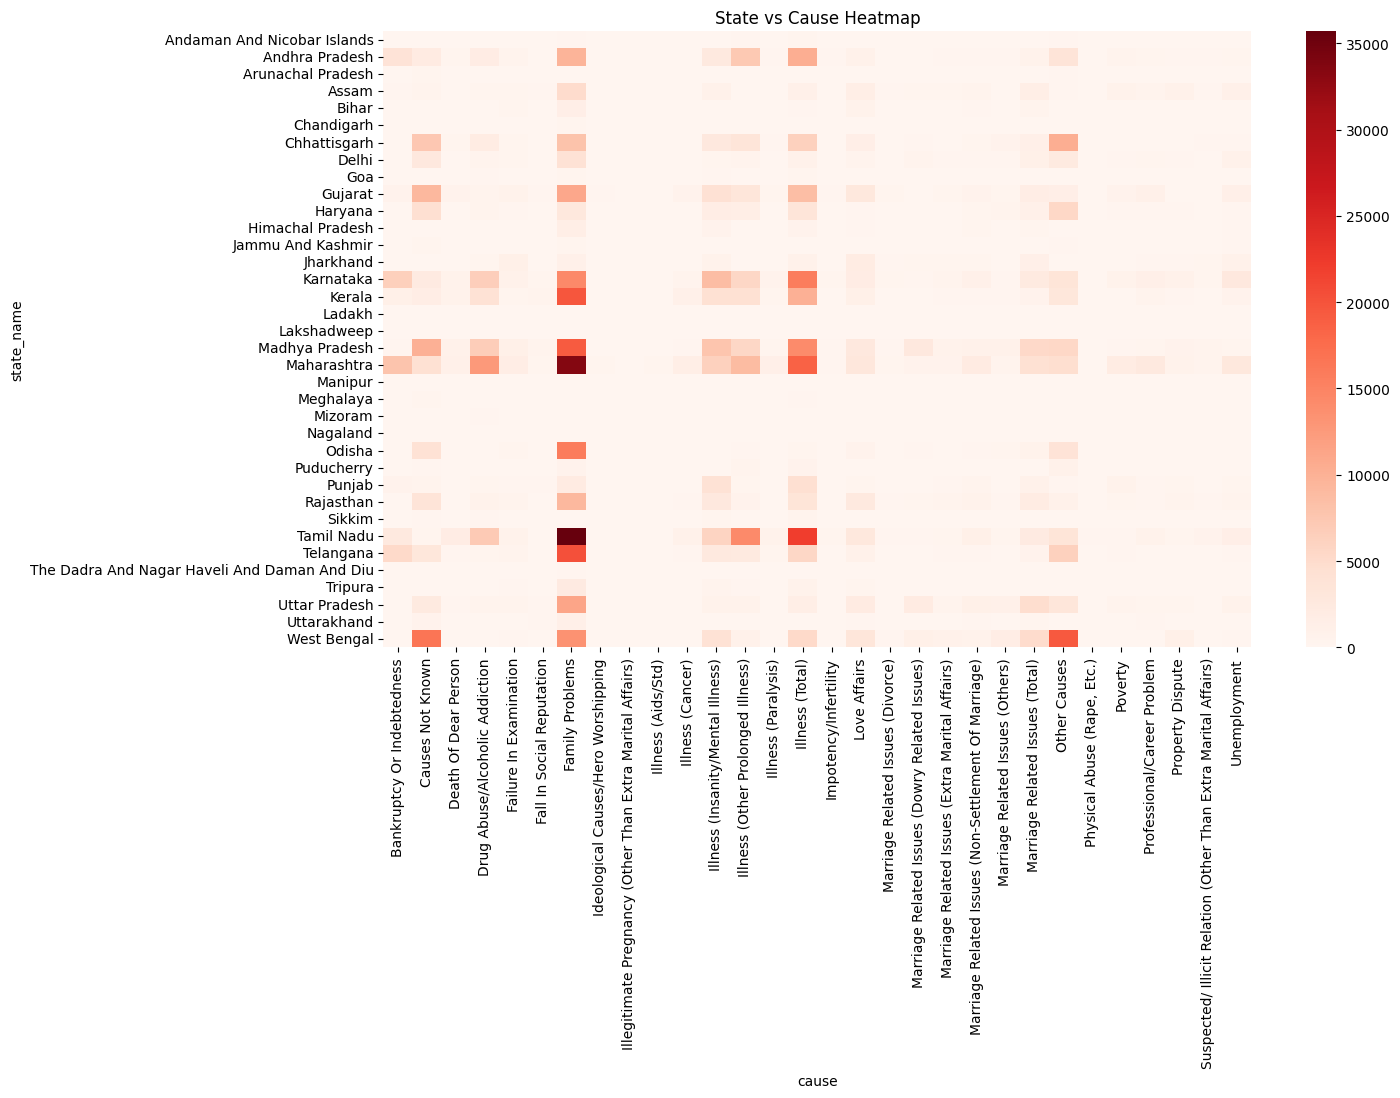

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(state_cause,
            cmap='Reds')

plt.title('State vs Cause Heatmap')

plt.show()

In [ ]:
causewise = data.groupby('cause')['number_of_deaths'].sum()

top_causes = causewise.sort_values(ascending=False).head(10)

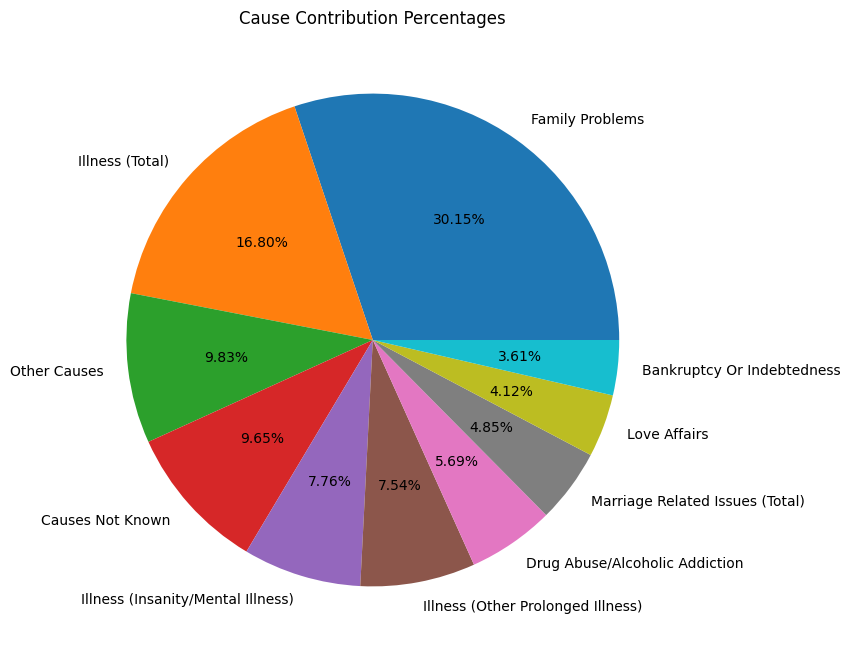

In [ ]:
#Cause contribution percentages
plt.figure(figsize=(8,8))
plt.pie(top_causes,
        labels=top_causes.index,
        autopct='%0.2f%%')
plt.title('Cause Contribution Percentages')
plt.show()

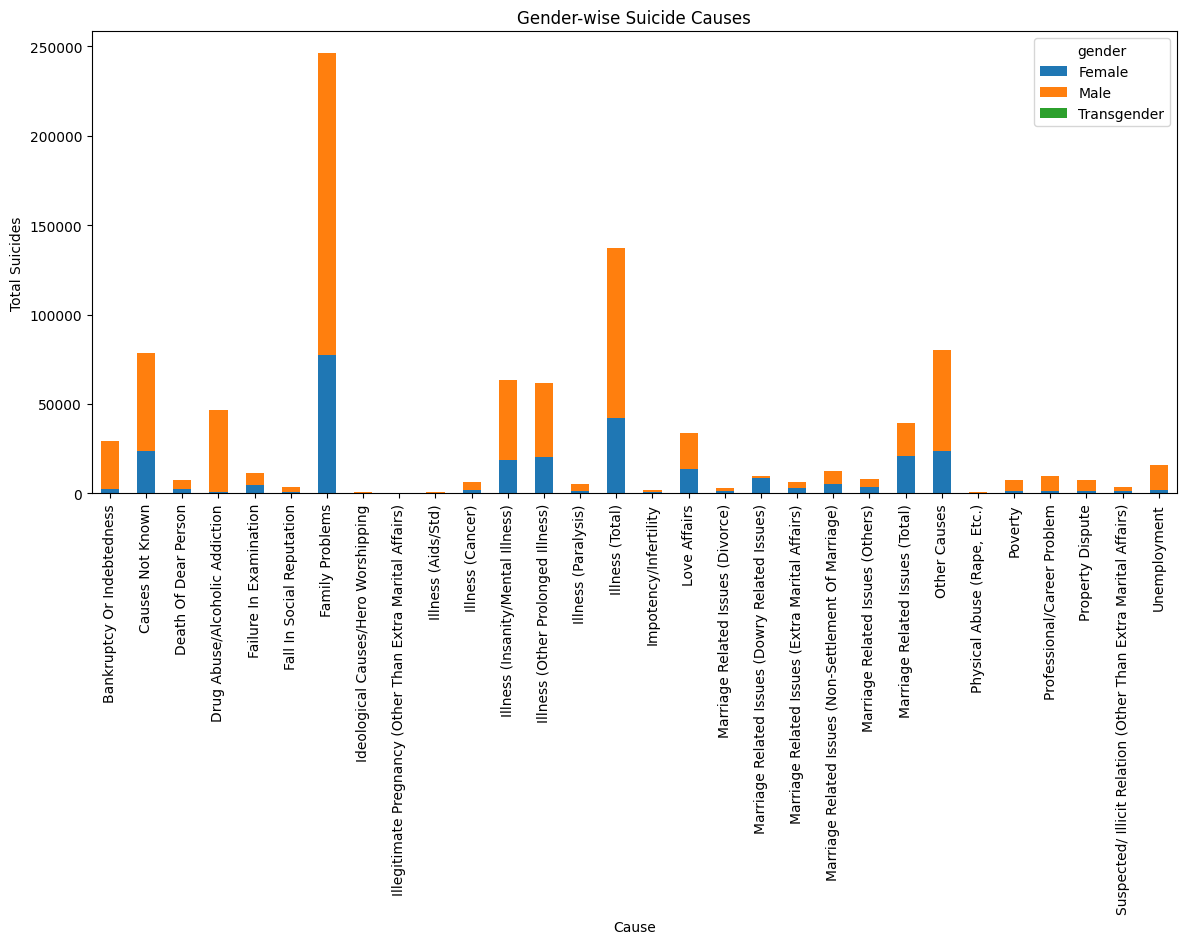

In [ ]:
#Gender-wise causes
gender_cause.plot(kind='bar',
                  stacked=True,
                  figsize=(14,6))
plt.title('Gender-wise Suicide Causes')
plt.xlabel('Cause')
plt.ylabel('Total Suicides')
plt.xticks(rotation=90)
plt.show()

MAIN-QUESTIONS:

1.Which causes are increasing rapidly over years?

family-problems,illnes(mental/emotional) causes are increasing rapidly over years.

2.Which states consistently report high suicide numbers?

maharastra and tamil-nadu states recorded consistentlyy high-number_of_deaths.

3.Is there any relationship between gender and suicide causes?

yes!!male(gender)have highest recorded highest-sucidal cases.

4.Which top 5 causes contribute to most suicides?

Family Problems	246089.0
Illness (Total)	137147.0
Other Causes	80231.0
Causes Not Known	78750.0
Illness (Insanity/Mental Illness)these are top-5 causes.

5.Which gender is more affected by unknown causes?

male(gender)is more affected by unknown causes than female.


****Top affected states:

Maharashtra

Tamil Nadu

Madhya Pradesh

Karnataka

West Bengal****

#***
he leading causes of suicides were:

Family Problems

Illness (Total)

Other Causes

Causes Not Known

Illness (Insanity/Mental Illness)
# ***

***
 Detect long-term trends and variations
across years

Suicide deaths showed a steady increasing
trend from 2018 to 2022.

The highest suicide count was recorded in 2022.

A noticeable rise was observed after 2020.


Year-wise trend:


2018 → 166,564

2019 → 170,548

2020 → 188,311

2021 → 202,382

2022 → 210,572
***

The following visualizations effectively explained the dataset:


Line charts for yearly trends

Bar charts for state-wise and cause-wise comparisons

Heatmaps for gender vs cause analysis

Pie charts for percentage distribution

#Generate actionable insights useful for awareness and policy discussions##
 Generate actionable insights useful for awareness and policy discussions.

Mental health awareness programs should focus heavily on family and illness-related stress.

High-risk states require stronger counseling and prevention initiatives.

Male-focused mental health concern may be necessary due to higher suicide rates.

Better reporting systems are needed to reduce the “Causes Not Known” category.

Early psychological support and awareness campaigns could help reduce long-term suicide growth.

PROJECT-DESCRPTION:

This project focuses on analyzing suicide patterns in India using EDA techniques. I performed data cleaning, trend analysis, gender comparison, and cause-wise analysis using Python libraries like Pandas and Seaborn to extract meaningful insights and visualize patterns across states and years.

